WEATHER DATA ANALYSIS PROJECT

[TASK 1] Generating Sample Weather Data...
✓ Weather data generated successfully!
  Dataset shape: (365, 4)

[TASK 2] Loading and Inspecting Data...

First 5 rows of the dataset:
        Date  Temperature   Humidity  Precipitation
0 2023-01-01     2.483571  55.987795      27.521941
1 2023-01-02    -0.689099  62.585192       0.000000
2 2023-01-03     3.247332  60.814356       7.793509
3 2023-01-04     7.635147  62.009154       0.000000
4 2023-01-05    -1.135221  53.645951      20.477036

Last 5 rows of the dataset:
          Date  Temperature   Humidity  Precipitation
360 2023-12-27     2.652260  56.440871       7.250083
361 2023-12-28     7.699240  58.808291      25.181570
362 2023-12-29    -0.523803  62.443424       0.000000
363 2023-12-30     2.017448  53.913971       0.000000
364 2023-12-31     3.452942  51.872686      19.066651

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 4 columns):

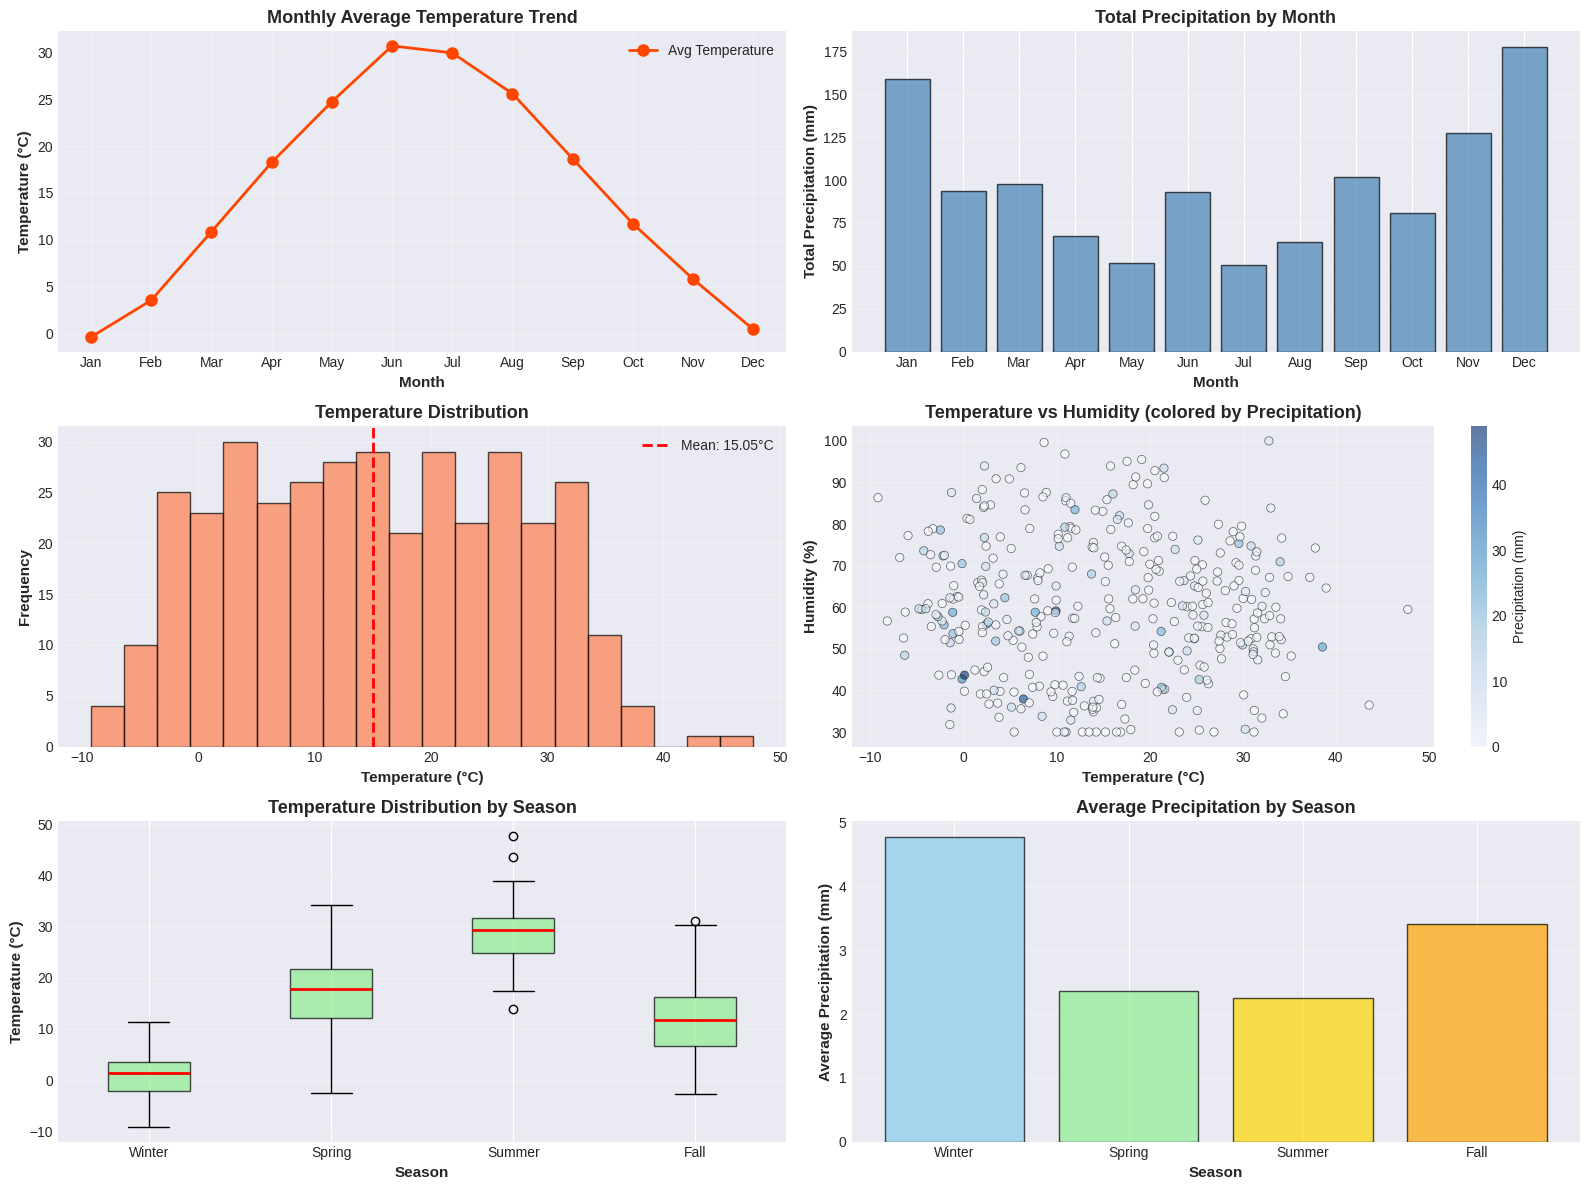

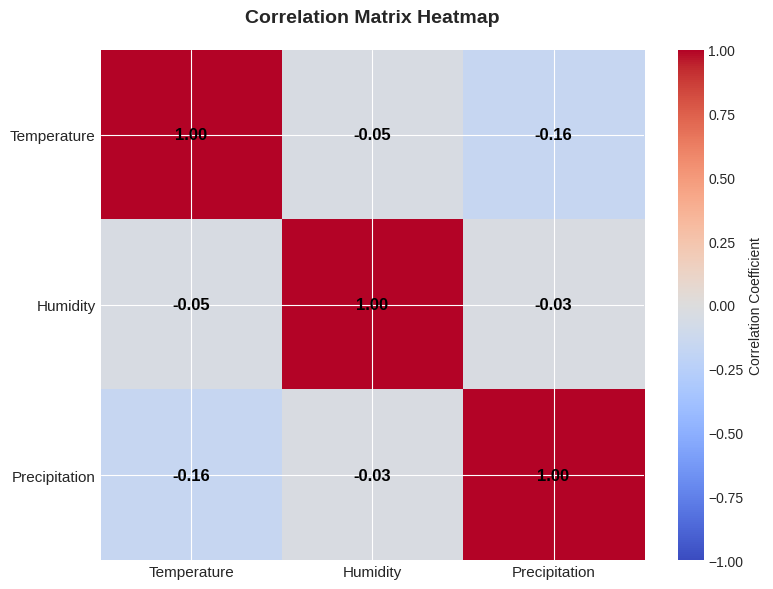

In [1]:
"""
Weather Data Analysis Project
Using NumPy, Pandas, and Matplotlib

Objective: Analyze historical weather data to study trends and patterns
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')

print("=" * 70)
print("WEATHER DATA ANALYSIS PROJECT")
print("=" * 70)

# ============================================================================
# TASK 1: GENERATE SAMPLE WEATHER DATA (Simulating CSV download)
# ============================================================================
print("\n[TASK 1] Generating Sample Weather Data...")

def generate_weather_data():
    """Generate synthetic weather data for one year"""
    np.random.seed(42)

    # Create date range
    start_date = datetime(2023, 1, 1)
    dates = [start_date + timedelta(days=i) for i in range(365)]

    # Generate temperature with seasonal pattern
    days = np.arange(365)
    base_temp = 15 + 15 * np.sin((days / 365) * 2 * np.pi - np.pi / 2)
    temperature = base_temp + np.random.normal(0, 5, 365)

    # Generate humidity (higher in summer)
    base_humidity = 60 + 20 * np.sin((days / 365) * 2 * np.pi)
    humidity = np.clip(base_humidity + np.random.normal(0, 10, 365), 30, 100)

    # Generate precipitation (30% chance of rain)
    precipitation = np.where(np.random.random(365) < 0.3,
                            np.random.exponential(10, 365), 0)

    # Create DataFrame
    df = pd.DataFrame({
        'Date': dates,
        'Temperature': temperature,
        'Humidity': humidity,
        'Precipitation': precipitation
    })

    return df

# Generate data
weather_df = generate_weather_data()
print("✓ Weather data generated successfully!")
print(f"  Dataset shape: {weather_df.shape}")

# ============================================================================
# TASK 2: LOAD AND INSPECT DATA
# ============================================================================
print("\n[TASK 2] Loading and Inspecting Data...")
print("\nFirst 5 rows of the dataset:")
print(weather_df.head())

print("\nLast 5 rows of the dataset:")
print(weather_df.tail())

print("\nDataset Information:")
print(weather_df.info())

print("\nData Types:")
print(weather_df.dtypes)

# ============================================================================
# TASK 3: DATA CLEANING
# ============================================================================
print("\n[TASK 3] Data Cleaning...")

# Check for missing values
print("\nMissing values in each column:")
print(weather_df.isnull().sum())

# Handle missing values (if any) - Forward fill method
weather_df = weather_df.fillna(method='ffill')

# Convert Date column to datetime format
weather_df['Date'] = pd.to_datetime(weather_df['Date'])
print("✓ Date column converted to datetime format")

# Add additional columns for analysis
weather_df['Month'] = weather_df['Date'].dt.month
weather_df['Month_Name'] = weather_df['Date'].dt.strftime('%B')
weather_df['Season'] = weather_df['Month'].apply(
    lambda x: 'Winter' if x in [12, 1, 2] else
              'Spring' if x in [3, 4, 5] else
              'Summer' if x in [6, 7, 8] else 'Fall'
)

print("✓ Added Month and Season columns")
print("\nCleaned dataset:")
print(weather_df.head())

# ============================================================================
# TASK 4: DESCRIPTIVE STATISTICS WITH NUMPY
# ============================================================================
print("\n[TASK 4] Descriptive Statistics with NumPy...")
print("=" * 70)

# Temperature statistics
temp_mean = np.mean(weather_df['Temperature'])
temp_median = np.median(weather_df['Temperature'])
temp_std = np.std(weather_df['Temperature'])

print("\nTEMPERATURE STATISTICS:")
print(f"  Mean:              {temp_mean:.2f}°C")
print(f"  Median:            {temp_median:.2f}°C")
print(f"  Standard Deviation: {temp_std:.2f}°C")
print(f"  Min:               {np.min(weather_df['Temperature']):.2f}°C")
print(f"  Max:               {np.max(weather_df['Temperature']):.2f}°C")

# Humidity statistics
humidity_mean = np.mean(weather_df['Humidity'])
humidity_median = np.median(weather_df['Humidity'])
humidity_std = np.std(weather_df['Humidity'])

print("\nHUMIDITY STATISTICS:")
print(f"  Mean:              {humidity_mean:.2f}%")
print(f"  Median:            {humidity_median:.2f}%")
print(f"  Standard Deviation: {humidity_std:.2f}%")
print(f"  Min:               {np.min(weather_df['Humidity']):.2f}%")
print(f"  Max:               {np.max(weather_df['Humidity']):.2f}%")

# Precipitation statistics
precip_mean = np.mean(weather_df['Precipitation'])
precip_median = np.median(weather_df['Precipitation'])
precip_std = np.std(weather_df['Precipitation'])

print("\nPRECIPITATION STATISTICS:")
print(f"  Mean:              {precip_mean:.2f} mm")
print(f"  Median:            {precip_median:.2f} mm")
print(f"  Standard Deviation: {precip_std:.2f} mm")
print(f"  Min:               {np.min(weather_df['Precipitation']):.2f} mm")
print(f"  Max:               {np.max(weather_df['Precipitation']):.2f} mm")

# ============================================================================
# TASK 5: MONTHLY AND SEASONAL ANALYSIS (Using Pandas GroupBy)
# ============================================================================
print("\n[TASK 5] Monthly and Seasonal Analysis...")
print("=" * 70)

# Monthly analysis
monthly_stats = weather_df.groupby('Month').agg({
    'Temperature': 'mean',
    'Humidity': 'mean',
    'Precipitation': ['sum', 'mean']
}).round(2)

print("\nMONTHLY STATISTICS:")
print(monthly_stats)

# Seasonal analysis
seasonal_stats = weather_df.groupby('Season').agg({
    'Temperature': ['mean', 'min', 'max'],
    'Humidity': 'mean',
    'Precipitation': ['sum', 'mean']
}).round(2)

print("\nSEASONAL STATISTICS:")
print(seasonal_stats)

# ============================================================================
# TASK 6: IDENTIFY EXTREME WEATHER (Using NumPy)
# ============================================================================
print("\n[TASK 6] Identifying Extreme Weather Events...")
print("=" * 70)

# Define extreme conditions
temp_threshold = temp_mean + 2 * temp_std  # 2 standard deviations above mean
cold_threshold = temp_mean - 2 * temp_std  # 2 standard deviations below mean
precip_threshold = np.percentile(weather_df['Precipitation'], 95)  # Top 5%

# Find extreme temperature days
extreme_hot = weather_df[weather_df['Temperature'] > temp_threshold]
extreme_cold = weather_df[weather_df['Temperature'] < cold_threshold]

# Find heavy precipitation days
heavy_rain = weather_df[weather_df['Precipitation'] > precip_threshold]

print(f"\nExtreme Hot Days (Temperature > {temp_threshold:.2f}°C): {len(extreme_hot)}")
print(extreme_hot[['Date', 'Temperature', 'Humidity', 'Precipitation']].head(10))

print(f"\nExtreme Cold Days (Temperature < {cold_threshold:.2f}°C): {len(extreme_cold)}")
print(extreme_cold[['Date', 'Temperature', 'Humidity', 'Precipitation']].head(10))

print(f"\nHeavy Precipitation Days (Precipitation > {precip_threshold:.2f} mm): {len(heavy_rain)}")
print(heavy_rain[['Date', 'Temperature', 'Humidity', 'Precipitation']].head(10))

# ============================================================================
# TASK 7: VISUALIZATIONS WITH MATPLOTLIB
# ============================================================================
print("\n[TASK 7] Creating Visualizations with Matplotlib...")
print("=" * 70)

# Create a figure with multiple subplots
fig = plt.figure(figsize=(16, 12))

# ---- Plot 1: Line Plot - Average Temperature Trends Over Time ----
ax1 = plt.subplot(3, 2, 1)
monthly_temp = weather_df.groupby('Month')['Temperature'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax1.plot(months, monthly_temp.values, marker='o', linewidth=2,
         markersize=8, color='orangered', label='Avg Temperature')
ax1.set_xlabel('Month', fontsize=11, fontweight='bold')
ax1.set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
ax1.set_title('Monthly Average Temperature Trend', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# ---- Plot 2: Bar Plot - Total Precipitation by Month ----
ax2 = plt.subplot(3, 2, 2)
monthly_precip = weather_df.groupby('Month')['Precipitation'].sum()
bars = ax2.bar(months, monthly_precip.values, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Month', fontsize=11, fontweight='bold')
ax2.set_ylabel('Total Precipitation (mm)', fontsize=11, fontweight='bold')
ax2.set_title('Total Precipitation by Month', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# ---- Plot 3: Histogram - Temperature Distribution ----
ax3 = plt.subplot(3, 2, 3)
ax3.hist(weather_df['Temperature'], bins=20, color='coral',
         edgecolor='black', alpha=0.7)
ax3.axvline(temp_mean, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {temp_mean:.2f}°C')
ax3.set_xlabel('Temperature (°C)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('Temperature Distribution', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ---- Plot 4: Scatter Plot - Temperature vs Humidity ----
ax4 = plt.subplot(3, 2, 4)
scatter = ax4.scatter(weather_df['Temperature'], weather_df['Humidity'],
                     c=weather_df['Precipitation'], cmap='Blues',
                     alpha=0.6, edgecolors='black', linewidth=0.5)
ax4.set_xlabel('Temperature (°C)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Humidity (%)', fontsize=11, fontweight='bold')
ax4.set_title('Temperature vs Humidity (colored by Precipitation)',
              fontsize=13, fontweight='bold')
plt.colorbar(scatter, ax=ax4, label='Precipitation (mm)')
ax4.grid(True, alpha=0.3)

# ---- Plot 5: Box Plot - Temperature by Season ----
ax5 = plt.subplot(3, 2, 5)
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_data = [weather_df[weather_df['Season'] == season]['Temperature'].values
               for season in season_order]
bp = ax5.boxplot(season_data, labels=season_order, patch_artist=True,
                 boxprops=dict(facecolor='lightgreen', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax5.set_xlabel('Season', fontsize=11, fontweight='bold')
ax5.set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
ax5.set_title('Temperature Distribution by Season', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# ---- Plot 6: Bar Plot - Average Precipitation by Season ----
ax6 = plt.subplot(3, 2, 6)
seasonal_precip = weather_df.groupby('Season')['Precipitation'].mean()
seasonal_precip_ordered = [seasonal_precip[season] for season in season_order]
bars = ax6.bar(season_order, seasonal_precip_ordered,
               color=['skyblue', 'lightgreen', 'gold', 'orange'],
               edgecolor='black', alpha=0.7)
ax6.set_xlabel('Season', fontsize=11, fontweight='bold')
ax6.set_ylabel('Average Precipitation (mm)', fontsize=11, fontweight='bold')
ax6.set_title('Average Precipitation by Season', fontsize=13, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('weather_analysis_plots.png', dpi=300, bbox_inches='tight')
print("✓ Visualizations created and saved as 'weather_analysis_plots.png'")

# ============================================================================
# ADDITIONAL ANALYSIS: CORRELATION MATRIX
# ============================================================================
print("\n[ADDITIONAL] Correlation Analysis...")
print("=" * 70)

correlation_matrix = weather_df[['Temperature', 'Humidity', 'Precipitation']].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Create correlation heatmap
fig2, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, fontsize=11)
ax.set_yticklabels(correlation_matrix.columns, fontsize=11)

# Add correlation values as text
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                      ha='center', va='center', color='black', fontsize=12,
                      fontweight='bold')

ax.set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.colorbar(im, ax=ax, label='Correlation Coefficient')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Correlation heatmap saved as 'correlation_heatmap.png'")

# ============================================================================
# SUMMARY REPORT
# ============================================================================
print("\n" + "=" * 70)
print("SUMMARY REPORT")
print("=" * 70)
print(f"\nTotal days analyzed: {len(weather_df)}")
print(f"Date range: {weather_df['Date'].min().date()} to {weather_df['Date'].max().date()}")
print(f"\nAverage Temperature: {temp_mean:.2f}°C")
print(f"Average Humidity: {humidity_mean:.2f}%")
print(f"Total Precipitation: {weather_df['Precipitation'].sum():.2f} mm")
print(f"Days with precipitation: {(weather_df['Precipitation'] > 0).sum()}")
print(f"\nExtreme weather events identified:")
print(f"  - Extreme hot days: {len(extreme_hot)}")
print(f"  - Extreme cold days: {len(extreme_cold)}")
print(f"  - Heavy rain days: {len(heavy_rain)}")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE!")
print("=" * 70)
print("\nGenerated files:")
print("  1. weather_analysis_plots.png - Main visualizations")
print("  2. correlation_heatmap.png - Correlation matrix")
print("\nAll tasks completed successfully! ✓")

# Display all plots
plt.show()